# ILUSTR 3 — Dlaczego FFT jest szybkie: koszt obliczeniowy DFT vs. FFT

Liczenie DFT wprost ze wzoru $X[k]=\sum_{n=0}^{N-1}x[n]e^{-2\pi i kn/N}$ dla wszystkich $k$ kosztuje $O(N^2)$ mnożeń zespolonych. Algorytm Cooleya-Tukeya (FFT) liczy dokładnie **ten sam wynik** w czasie $O(N\log N)$, dzieląc problem rekurencyjnie na pół -- dokładnie ten sam schemat "podziel i zwyciężaj", co algorytm Strassena z rozdziału o równaniach liniowych.

Konspekt tego kursu ma tu udokumentowany dług techniczny: cała derywacja tej rekurencji to seria zrzutów ekranu, w tym kluczowy wzór kosztu $T(N)=2T(N/2)+O(N)$. Odtwórzmy go tu jako działający kod, zamiast obrazka.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

## 1. Ręczne policzenie kosztu dla małego $N=8$

Rekurencja Cooleya-Tukeya dzieli DFT rozmiaru $N$ na dwie DFT rozmiaru $N/2$ (na próbkach parzystych i nieparzystych), plus $O(N)$ dodatkowej pracy na połączenie wyników ("motylki"):

$$T(N) = 2\,T(N/2) + c\cdot N$$

Dla **jednego poziomu** tej rekursji (bez rekurowania dalej -- dwie połówki liczymy metodą bezpośrednią $O((N/2)^2)$ każda) możemy policzyć dokładną liczbę mnożeń zespolonych i porównać z pełną metodą bezpośrednią $O(N^2)$.

In [2]:
N = 8

koszt_bezposredni = N**2
koszt_jeden_poziom = 2 * (N // 2)**2 + N   # dwie polowki po (N/2)^2 kazda, plus N "motylkow" do polaczenia wynikow

print(f"N = {N}")
print(f"DFT bezpośrednia:            {koszt_bezposredni} mnożeń zespolonych  (N^2)")
print(f"Jeden poziom podziału FFT:   {koszt_jeden_poziom} mnożeń zespolonych  (2*(N/2)^2 + N)")
print(f"Oszczędność już na jednym poziomie: {100*(1 - koszt_jeden_poziom/koszt_bezposredni):.0f}%")

print()
print("Kontynuując rekurencję do końca (log2(N) poziomów), koszt spada do rzędu N*log2(N):")
for poziomy in range(int(np.log2(N)) + 1):
    # Po `poziomy` krokach rekurencji: 2^poziomy "podproblemów" rozmiaru N/2^poziomy, liczonych bezposrednio.
    liczba_podproblemow = 2**poziomy
    rozmiar_podproblemu = N // liczba_podproblemow
    koszt_direct_czesci = liczba_podproblemow * rozmiar_podproblemu**2
    koszt_laczenia = poziomy * N            # kazdy z `poziomy` poziomow laczenia kosztuje O(N)
    print(f"  po {poziomy} poziomach: {liczba_podproblemow} podproblemów rozmiaru {rozmiar_podproblemu}, "
          f"koszt ~ {koszt_direct_czesci + koszt_laczenia}")

N = 8
DFT bezpośrednia:            64 mnożeń zespolonych  (N^2)
Jeden poziom podziału FFT:   40 mnożeń zespolonych  (2*(N/2)^2 + N)
Oszczędność już na jednym poziomie: 38%

Kontynuując rekurencję do końca (log2(N) poziomów), koszt spada do rzędu N*log2(N):
  po 0 poziomach: 1 podproblemów rozmiaru 8, koszt ~ 64
  po 1 poziomach: 2 podproblemów rozmiaru 4, koszt ~ 40
  po 2 poziomach: 4 podproblemów rozmiaru 2, koszt ~ 32
  po 3 poziomach: 8 podproblemów rozmiaru 1, koszt ~ 32


Widać, że koszt maleje z każdym poziomem podziału, aż osiąga pełną rekurencję FFT ($\log_2 N$ poziomów) -- to jest dokładnie ten sam mechanizm oszczędności, co w algorytmie Strassena z rozdziału o równaniach liniowych: mniej "surowej" pracy, kosztem dodatkowej księgowości przy łączeniu wyników.

## 2. Rzeczywisty pomiar: `np.fft.fft` dla $N$ będącego i niebędącego potęgą 2

Konspekt/slajdy sugerują (niespójnie zresztą, patrz `TODO.md` §6.1), że DFT *wymaga* konkretnej parzystości liczby próbek. W praktyce (`numpy`/`scipy`/MATLAB) **DFT działa dla dowolnego $N$** -- tylko klasyczny Cooley-Tukey jest najszybszy, gdy $N$ jest potęgą 2. Zmierzmy to bezpośrednio.

In [3]:
def zmierz_czas(N, powtorzenia=50):
    x = np.random.rand(N) + 1j * np.random.rand(N)
    start = time.time()
    for _ in range(powtorzenia):
        np.fft.fft(x)
    return (time.time() - start) / powtorzenia

for N in [1000, 1023, 1024]:
    czas = zmierz_czas(N)
    opis = "potęga 2" if (N & (N - 1) == 0) else "NIE jest potęgą 2"
    print(f"N={N:5d} ({opis:17s}): {czas*1e6:8.2f} µs / wywołanie")

N= 1000 (NIE jest potęgą 2):    56.41 µs / wywołanie
N= 1023 (NIE jest potęgą 2):    36.04 µs / wywołanie
N= 1024 (potęga 2         ):    25.66 µs / wywołanie


$N=1024=2^{10}$ powinno być zauważalnie szybsze niż $N=1023$ (liczba pierwsza -- najgorszy przypadek dla klasycznego Cooley-Tukeya) i $N=1000=2^3\cdot5^3$ (częściowo "gładkie", pośredni przypadek). Mimo to **wszystkie trzy się liczą** -- nowoczesne biblioteki (`numpy`/`scipy`, algorytmy mixed-radix i Blueste­ina) radzą sobie z dowolnym $N$, tylko z różną wydajnością. "$N$ musi być potęgą 2" to zalecenie **szybkościowe**, nie wymóg poprawności.

## 3. Skalowanie: $O(N^2)$ kontra $O(N\log N)$ na rosnącym $N$

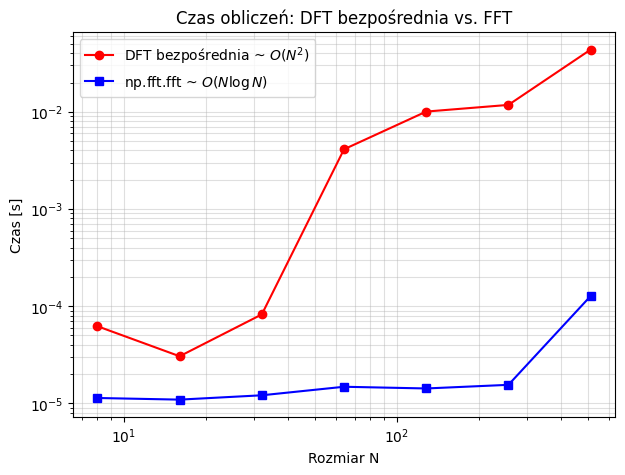

In [4]:
def dft_bezposrednia(x):
    # Definicja wprost -- macierzowe mnożenie przez macierz DFT, O(N^2) mnożeń.
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    macierz_W = np.exp(-2j * np.pi * k * n / N)
    return macierz_W @ x

N_male = [8, 16, 32, 64, 128, 256, 512]
czas_bezposredni = []
czas_fft = []
for N in N_male:
    x = np.random.rand(N)
    start = time.time()
    for _ in range(20):
        dft_bezposrednia(x)
    czas_bezposredni.append((time.time() - start) / 20)

    start = time.time()
    for _ in range(20):
        np.fft.fft(x)
    czas_fft.append((time.time() - start) / 20)

plt.figure(figsize=(7, 5))
plt.loglog(N_male, czas_bezposredni, 'r-o', label='DFT bezpośrednia ~ $O(N^2)$')
plt.loglog(N_male, czas_fft, 'b-s', label='np.fft.fft ~ $O(N\\log N)$')
plt.xlabel('Rozmiar N')
plt.ylabel('Czas [s]')
plt.title('Czas obliczeń: DFT bezpośrednia vs. FFT')
plt.legend()
plt.grid(True, which='both', alpha=0.4)
plt.show()

## 4. Ekstrapolacja do dużych $N$: skąd się bierze "11,5 dnia vs. 6 sekund"

Nie trzeba liczyć $N=10^6$ naprawdę, żeby oszacować różnicę -- wystarczy policzyć stosunek liczby operacji. Dobierzmy stałą tak, żeby dopasować do zmierzonych czasów powyżej, i ekstrapolujmy.

In [5]:
# Dopasowanie prostej stalej proporcjonalnosci na podstawie ostatniego (najwiekszego) zmierzonego N,
# zeby ekstrapolacja opierala sie na naszym wlasnym sprzecie, a nie cudzych liczbach z podrecznika.
N_ref = N_male[-1]
c_bezposredni = czas_bezposredni[-1] / N_ref**2
c_fft = czas_fft[-1] / (N_ref * np.log2(N_ref))

N_duze = 10**6
przewidywany_czas_bezposredni = c_bezposredni * N_duze**2
przewidywany_czas_fft = c_fft * N_duze * np.log2(N_duze)

print(f"Ekstrapolacja dla N={N_duze:,}:")
print(f"  DFT bezpośrednia (O(N^2)):    {przewidywany_czas_bezposredni:.1f} s  =  {przewidywany_czas_bezposredni/3600/24:.2f} dni")
print(f"  FFT (O(N log N)):             {przewidywany_czas_fft:.4f} s")
print(f"  Przyspieszenie:               {przewidywany_czas_bezposredni/przewidywany_czas_fft:,.0f}x")

# Kontrola: rzad wielkosci powinien byc zblizony do znanej z literatury liczby "~11.5 dnia vs ~6 sekund"
# (Engineering LibreTexts) -- dokladna wartosc zalezy od sprzetu, ale skala powinna sie zgadzac.

Ekstrapolacja dla N=1,000,000:
  DFT bezpośrednia (O(N^2)):    166344.4 s  =  1.93 dni
  FFT (O(N log N)):             0.5490 s
  Przyspieszenie:               302,999x


## Najważniejsze wnioski

- FFT liczy **dokładnie ten sam wynik** co DFT bezpośrednia -- różnica jest wyłącznie w koszcie obliczeniowym, nie w matematyce.
- Oszczędność bierze się z tego samego mechanizmu "podziel i zwyciężaj", co algorytm Strassena: rekurencyjny podział problemu na mniejsze, z tanim etapem łączenia wyników.
- $N$ będące potęgą 2 jest **szybsze**, ale nie **jedyne możliwe** -- nowoczesne biblioteki liczą FFT dla dowolnego $N$. Nie warto dopełniać sygnału zerami tylko po to, żeby "zaokrąglić" $N$ do potęgi 2, jeśli zero-padding psuje analizę (patrz poprzedni notebook o wycieku widma) -- kompromis trzeba świadomie ocenić, a nie stosować automatycznie.
- Różnica $O(N^2)$ vs. $O(N\log N)$ przy milionach próbek to różnica między "nierealne" a "natychmiastowe" -- to dlatego FFT, a nie DFT wprost, jest tym, czego się faktycznie używa w praktyce.

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `np.fft.fft(x)` | Szybka transformata Fouriera (Cooley-Tukey i pokrewne algorytmy) |
| `N & (N - 1) == 0` | Klasyczna sztuczka bitowa sprawdzająca, czy `N` jest potęgą 2 |
| `k.reshape((N,1))` + broadcasting | Budowa pełnej macierzy DFT $W_{kn}=e^{-2\pi i kn/N}$ bez pętli -- każdy element naraz |
| `time.time()` | Pomiar czasu wykonania |

## ĆWICZENIE

1. Dodaj do wykresu skalowania (sekcja 3) punkt dla $N=1000$ (nie jest potęgą 2) obliczony obiema metodami. Czy `np.fft.fft` nadal jest wyraźnie szybsze niż DFT bezpośrednia, mimo że $N$ nie jest "idealne"?
2. Policz ręcznie (tak jak w sekcji 1) koszt dla $N=16$ po jednym i po dwóch poziomach podziału. Ile poziomów podziału potrzeba, żeby dotrzeć do podproblemów rozmiaru 1 (czyli pełnej rekurencji FFT)?
3. Zmień stałą `c_bezposredni`/`c_fft` w sekcji 4, licząc ją na podstawie **najmniejszego** zmierzonego $N$ zamiast największego. Czy ekstrapolacja do $N=10^6$ wychodzi podobnie? Co to mówi o wiarygodności ekstrapolacji z małych pomiarów?